Built a seperate notebook to showcase how to load and use the trained model.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler, random_split
import numpy as np
import matplotlib.pyplot as plt
import os
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize
from torchsummary import summary
from tqdm import tqdm
import sys

from PINN_model import PINNLensingClassifier, LensingNpyDataset
sys.path.insert(0,'..')
from training import predict

Loading Trained Model

In [4]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

MODEL_PATH = "Results/pinn_lensing_final.pth"
CLASSES = ['test_lenses', 'test_nonlenses']

model = PINNLensingClassifier(num_classes=len(CLASSES), img_size=64, dropout=0.5)

checkpoint = torch.load(MODEL_PATH, map_location=device)
state_dict = checkpoint["model_state_dict"] if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint else checkpoint
model.load_state_dict(state_dict)
model.to(device)
model.eval()

print(f"Device: {device}")
print(f"Learned Einstein radius θ_E: {model.get_einstein_radius():.4f}")
print("Checkpoint loaded successfully.")

Device: cuda
Learned Einstein radius θ_E: 0.2920
Checkpoint loaded successfully.


Setting up transform for Test Set

In [5]:
transform = transforms.Compose([
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])


Loading test data for evaluation

In [6]:
test_dir= os.path.join('dataset','test')
test_dataset=LensingNpyDataset(root_dir=test_dir, transform=transform)
test_loader=DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

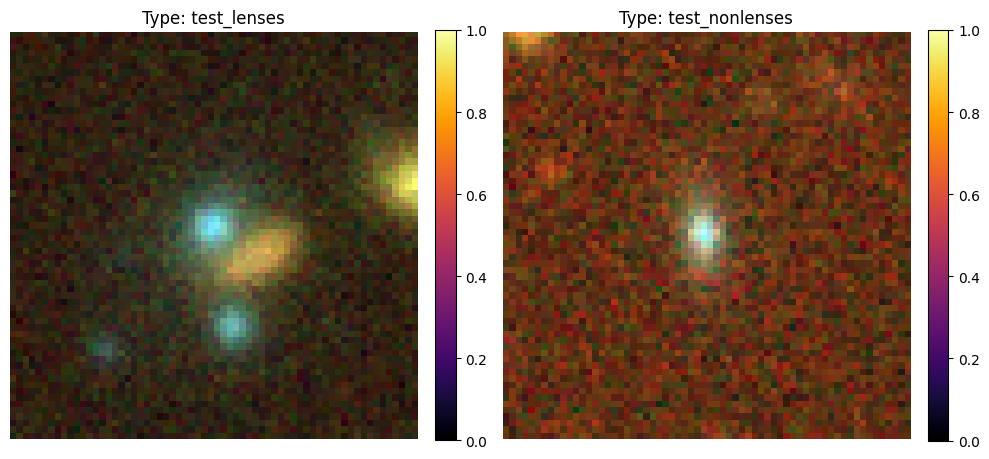

In [8]:
fig, axes = plt.subplots(1,2, figsize=(10,5))

for i,cl in enumerate(CLASSES):
    class_path = os.path.join(test_dir,cl)
    file_name = [f for f in os.listdir(class_path) if f.endswith('.npy')][0]
    img_array = np.load(os.path.join(class_path,file_name))
    
    # Squeeze and transpose to (H, W, C) if channels-first
    img_plot = img_array.squeeze()
    if img_plot.ndim == 3 and img_plot.shape[0] in (1, 3, 4):
        img_plot = np.transpose(img_plot, (1, 2, 0))
    
    im=axes[i].imshow(img_plot,cmap='inferno')
    axes[i].set_title(f"Type: {cl}")
    axes[i].axis("off")
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
    
plt.tight_layout()
plt.show()

Running Predictions on Test set

In [9]:
probabilities=predict(model, test_loader, device)
predictions=torch.argmax(probabilities,dim=1)

Predicting:   0%|          | 0/615 [00:00<?, ?it/s]

Confusion Matrix On Test Set

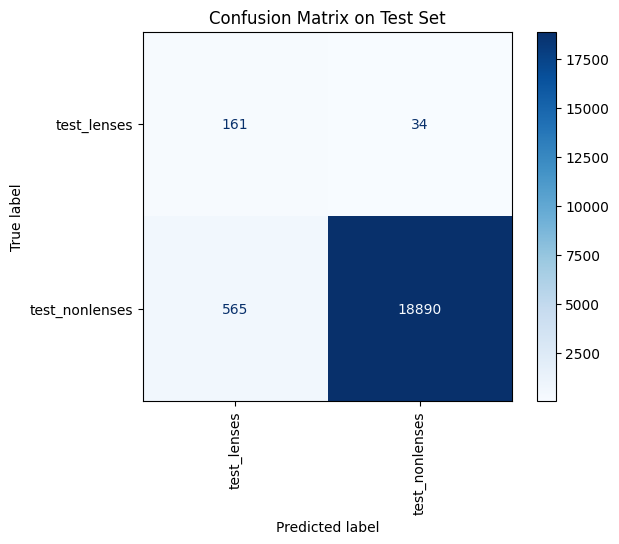

In [10]:
targets=[]

for _, labels in test_loader:
    targets.extend(labels.cpu().numpy())
    
cm=confusion_matrix(targets, predictions.cpu().numpy())
disp=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(cmap='Blues', xticks_rotation="vertical")
plt.title("Confusion Matrix on Test Set")
plt.show()

In [13]:
def plot_final_roc(model, dataloader, device, classes, title_suffix=""):
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    n_classes = len(classes)
    plt.figure(figsize=(8, 6))

    for i in range(n_classes):
        # For each class, treat it as positive vs all others
        binary_labels = (all_labels == i).astype(int)
        fpr, tpr, _ = roc_curve(binary_labels, all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class {classes[i]} (AUC = {roc_auc:.4f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {title_suffix}')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

ROC Curves

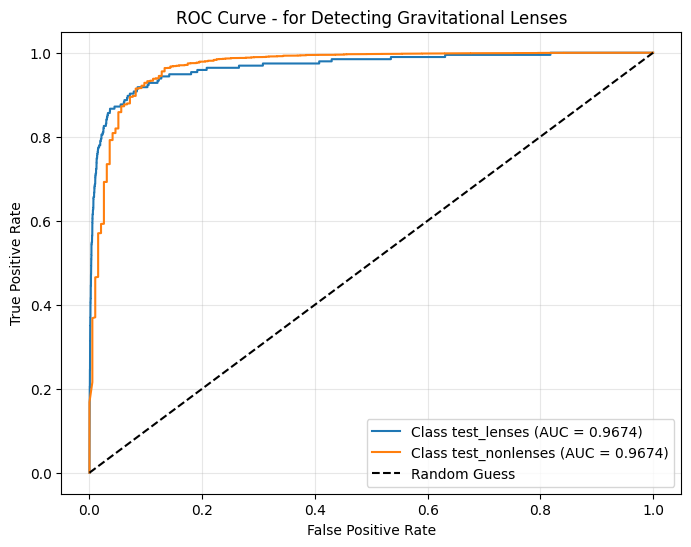

In [14]:
plot_final_roc(model, test_loader, device, CLASSES, "for Detecting Gravitational Lenses")